In [1]:
import torch

# --- Dummy Parameters (based on the M=2 example) ---
M = 2  # Number of inducing points
# These would be the learnable variational parameters
m_params = torch.randn(M, requires_grad=True)
nu_tilde_param = torch.tensor(5.0, requires_grad=True) # Must be > 2
sigma_params = torch.rand(M, requires_grad=True) + 0.1 # Must be > 0

print(f"--- Running Dummy FIM Inverse Demo (M={M}) ---")
print(f"Variational Parameters:")
print(f"  m = {m_params.data}")
print(f"  ν̃ = {nu_tilde_param.data:.4f}")
print(f"  σ = {sigma_params.data}\n")

# ==============================================================================
# Partition 1: The Mean Component (F̃ᵐ)⁻¹
#
# PROPERTY: F̃ᵐ is a DIAGONAL matrix with positive elements.
# Therefore, it's always invertible and its inverse is easy to compute.
# ==============================================================================
print("--- Partition 1: The Mean Component (F̃ᵐ) ---")

# DUMMY CALCULATION:
# We create a dummy diagonal matrix with positive entries.
# This stands in for the actual calculation from Equation (33).
F_m_tilde_diag_elements = torch.rand(M) + 1.0  # Dummy positive values
F_m_tilde = torch.diag(F_m_tilde_diag_elements)

print("F̃ᵐ (is diagonal and positive):")
print(F_m_tilde, "\n")

# INVERTIBILITY CHECK:
# A diagonal matrix is invertible if no diagonal element is zero. Ours are all positive.
assert torch.all(torch.diag(F_m_tilde) > 0), "F̃ᵐ is not invertible!"

# INVERSION:
# The inverse is simply the reciprocal of the diagonal elements.
F_m_tilde_inv = torch.diag(1.0 / F_m_tilde_diag_elements)

print("(F̃ᵐ)⁻¹ (the inverted block):")
print(F_m_tilde_inv, "\n")


# ==============================================================================
# Partition 2: The Degrees of Freedom and Scale Component (Aᵥₛ)⁻¹
#
# PROPERTY: Aᵥₛ is a SYMMETRIC POSITIVE DEFINITE matrix.
# It is dense, not diagonal. A positive definite matrix is always invertible.
# ==============================================================================
print("--- Partition 2: The ν̃ and S Component (Aᵥₛ) ---")

dim_A = M + 1  # The size of this block is (M+1) x (M+1)

# DUMMY CALCULATION:
# A standard way to create a random symmetric positive definite (SPD) matrix is
# to compute B @ B.T and add a small "nugget" to the diagonal for stability.
# This stands in for the matrix constructed from Equations (35-37).
B = torch.randn(dim_A, dim_A)
# Add a small epsilon * Identity for guaranteed positive definiteness
A_nuS = B @ B.T + 1e-4 * torch.eye(dim_A)

print("Aᵥₛ (is symmetric and positive definite):")
print(A_nuS, "\n")


# INVERTIBILITY CHECK:
# A matrix is positive definite if all its eigenvalues are positive.
# Positive definite matrices are always invertible.
eigenvalues = torch.linalg.eigvalsh(A_nuS)
print(f"Eigenvalues of Aᵥₛ: {eigenvalues.numpy()}")
assert torch.all(eigenvalues > 0), "Aᵥₛ is not positive definite, so not invertible!"
print("All eigenvalues are positive -> Aᵥₛ is invertible.\n")

# INVERSION:
# For a dense matrix, we use a standard, robust inversion routine.
A_nuS_inv = torch.inverse(A_nuS)

print("(Aᵥₛ)⁻¹ (the inverted block):")
print(A_nuS_inv, "\n")


# ==============================================================================
# Final Assembly: The Full Inverse FIM F(θ)⁻¹
#
# PROPERTY: The full inverse FIM is a block-diagonal matrix built
# from the two inverted components we just computed.
# ==============================================================================
print("--- Final Assembly of F(θ)⁻¹ ---")

total_dim = F_m_tilde_inv.shape[0] + A_nuS_inv.shape[0]
F_inv = torch.zeros(total_dim, total_dim)

# Place the inverted blocks onto the diagonal of the final matrix
F_inv[:M, :M] = F_m_tilde_inv
F_inv[M:, M:] = A_nuS_inv

print("Final F(θ)⁻¹ (block-diagonal form):")
print(F_inv)

--- Running Dummy FIM Inverse Demo (M=2) ---
Variational Parameters:
  m = tensor([-2.8287, -2.5712])
  ν̃ = 5.0000
  σ = tensor([1.0105, 0.5107])

--- Partition 1: The Mean Component (F̃ᵐ) ---
F̃ᵐ (is diagonal and positive):
tensor([[1.3516, 0.0000],
        [0.0000, 1.3811]]) 

(F̃ᵐ)⁻¹ (the inverted block):
tensor([[0.7399, 0.0000],
        [0.0000, 0.7241]]) 

--- Partition 2: The ν̃ and S Component (Aᵥₛ) ---
Aᵥₛ (is symmetric and positive definite):
tensor([[ 1.3442,  0.2775, -0.2744],
        [ 0.2775,  0.4182,  0.2550],
        [-0.2744,  0.2550,  1.8241]]) 

Eigenvalues of Aᵥₛ: [0.27433175 1.3534157  1.9587324 ]
All eigenvalues are positive -> Aᵥₛ is invertible.

(Aᵥₛ)⁻¹ (the inverted block):
tensor([[ 0.9596, -0.7922,  0.2551],
        [-0.7922,  3.2680, -0.5760],
        [ 0.2551, -0.5760,  0.6671]]) 

--- Final Assembly of F(θ)⁻¹ ---
Final F(θ)⁻¹ (block-diagonal form):
tensor([[ 0.7399,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.7241,  0.0000,  0.0000,  0.0000]

In [ ]:
import logging
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from linear_operator.operators import to_linear_operator
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
from torch.utils.data import DataLoader, TensorDataset

# Assuming these are in a local .utils file as in the original code
from student.constants import EPSILON, JITTER
from student.kernels import matern52_kernel, rbf_kernel
from student.priors import GammaPrior, LogNormalPrior
from student.utils import kl_mvt_empirical, sample_mvt



class XuSparseTPR(nn.Module):
    """
    Sparse Variational Student-t Process Regression (SVTP-MC).
    This implementation follows the Monte Carlo approach for the KL divergence
    as proposed by Xu et al. (2023).
    """
    def __init__(
        self, 
        X, y, M, 
        kernel='rbf',hyper_settings=None, 
        inducing_init_method="kmeans", 
        device=None
    ):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
            
        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        self.M = M
        dtype = self.X_full.dtype

        # --- Priors for Hyperparameters ---
        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.outputscale_prior = GammaPrior(2.0, 0.15)
        self.dof_func_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.dof_lik_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.noisescale_prior = LogNormalPrior(loc=-4.0, scale=1.0)

        # --- Initialize Hyperparameters ---
        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        
        # Register hyperparameters as learnable parameters
        self.log_lengthscale = nn.Parameter(torch.log(hyperparameters['lengthscale']))
        self.log_outputscale = nn.Parameter(torch.log(hyperparameters['outputscale']))
        self.log_dof_func = nn.Parameter(torch.log(hyperparameters['dof_func']))
        self.log_dof_lik = nn.Parameter(torch.log(hyperparameters['dof_lik']))
        self.log_noisescale = nn.Parameter(torch.log(hyperparameters['noisescale']))

        # --- Inducing Points ---
        self.Z = nn.Parameter(self._initialize_inducing_points(method=inducing_init_method))

        # --- Variational Parameters for q(u) ---
        self.m_u = nn.Parameter(torch.zeros(self.M, 1, device=self.device, dtype=dtype))
        self.chol_S_u = nn.Parameter(torch.eye(self.M, device=self.device, dtype=dtype))
        self.log_dof_q = nn.Parameter(torch.log(torch.tensor(4.0, device=self.device, dtype=dtype)))

        # Set kernel function
        if kernel in (None, "rbf"): self.kernel = rbf_kernel
        elif kernel == "matern52": self.kernel = matern52_kernel
        else:
            logging.info("Unknown kernel specified. Defaulting to RBF kernel.")
            self.kernel = rbf_kernel

        self.to(self.device)

    def _initialize_inducing_points(self, method="kmeans"):
        if self.N >= self.M:
            if method == "kmeans":
                kmeans = KMeans(n_clusters=self.M, random_state=42, n_init='auto').fit(self.X_full.cpu().numpy())
                Z_init = torch.from_numpy(kmeans.cluster_centers_)
            elif method == "random":
                indices = np.random.choice(self.N, self.M, replace=False)
                Z_init = self.X_full[indices].clone()
            else: raise ValueError(f"Unknown init method: {method}")
        else: # If M > N, just use random points from X with replacement
            indices = np.random.choice(self.N, self.M, replace=True)
            Z_init = self.X_full[indices].clone()
        return Z_init.to(dtype=self.X_full.dtype, device=self.device)

    def _initialize_hyperparameters(self, hyper_settings=None):
        self.hyper_optim_mode = {}
        dtype = self.X_full.dtype
        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'dof_func': {'prior': self.dof_func_prior, 'is_vector': False},
            'dof_lik': {'prior': self.dof_lik_prior, 'is_vector': False},
            'noisescale': {'prior': self.noisescale_prior, 'is_vector': False}
        }
        initialized_params = {}
        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode = settings.get("optim", "MLE")
            init_val = settings.get("init", None)
            if mode not in ['MLE', 'MAP', 'FIX']: raise ValueError(f"Invalid mode '{mode}' for '{name}'.")
            self.hyper_optim_mode[name] = mode
            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=dtype)
                if name.startswith('dof'): final_value = final_value.clamp(min=2.0)
                logging.info(f"Sampled initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            else:
                final_value = torch.as_tensor(init_val, dtype=dtype, device=self.device)
                logging.info(f"Using provided initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            initialized_params[name] = final_value
        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        initialized_params['lengthscale'] = ls
        return initialized_params

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_lengthscale).clamp(min=EPSILON),
            "outputscale": torch.exp(self.log_outputscale).clamp(min=EPSILON),
            "dof_func": torch.exp(self.log_dof_func).clamp(min=EPSILON),
            "dof_lik": torch.exp(self.log_dof_lik).clamp(min=EPSILON),
            "noisescale": torch.exp(self.log_noisescale).clamp(min=EPSILON),
            "dof_q": torch.exp(self.log_dof_q).clamp(min=EPSILON),
        }

    def _calculate_log_prior(self, params):
        log_prior = torch.tensor(0.0, device=self.device, dtype=params['lengthscale'].dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP': log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        if self.hyper_optim_mode['outputscale'] == 'MAP': log_prior += self.outputscale_prior.log_prob(params['outputscale'])
        if self.hyper_optim_mode['dof_func'] == 'MAP': log_prior += self.dof_func_prior.log_prob(params['dof_func'])
        if self.hyper_optim_mode['dof_lik'] == 'MAP': log_prior += self.dof_lik_prior.log_prob(params['dof_lik'])
        if self.hyper_optim_mode['noisescale'] == 'MAP': log_prior += self.noisescale_prior.log_prob(params['noisescale'])
        return log_prior

    def calculate_elbo(self, X_batch, y_batch, num_samples=100):
        params = self._get_hyperparams()
        batch_size = X_batch.shape[0]

        # --- 1. Compute Expected Log-Likelihood ---
        # Sample u from q(u) ~ ST(m_u, S_u, dof_q)
        scale_tril_q = torch.tril(self.chol_S_u)
        u_samples = sample_mvt(self.m_u, scale_tril_q, params['dof_q'], num_samples) # [M, 1, num_samples]

        # Compute kernels
        K_ZZ_base = self.kernel(self.Z, self.Z, params['lengthscale'], params['outputscale'])
        K_ZZ_op = to_linear_operator(K_ZZ_base).add_jitter(JITTER)
        K_XZ_batch = self.kernel(X_batch, self.Z, params['lengthscale'], params['outputscale'])
        K_XX_batch_diag = self.kernel(X_batch, X_batch, params['lengthscale'], params['outputscale']).diag()

        # Get parameters for p(f|u) for each u_sample
        K_ZZ_inv_u = K_ZZ_op.solve(u_samples.squeeze(1)) # [M, num_samples]
        mu_f_cond = K_XZ_batch @ K_ZZ_inv_u # [batch_size, num_samples]

        beta = (u_samples.squeeze(1) * K_ZZ_inv_u).sum(0) # [num_samples]
        dof_f_cond = params['dof_func'] + self.M

        K_XZ_K_inv = K_ZZ_op.solve(K_XZ_batch.T).T
        term2 = (K_XZ_K_inv * K_XZ_batch).sum(1) # [batch_size]
        scale_base = K_XX_batch_diag - term2 # [batch_size]

        scale_factor = (params['dof_func'] + beta) / dof_f_cond # [num_samples]
        scale_f_cond_sq = scale_base.unsqueeze(1) * scale_factor.unsqueeze(0) # [batch_size, num_samples]

        # We now have the parameters for p(f|u). We can compute p(y|f) using these.
        # This gives us a distribution over y for each u_sample.
        lik_dist = torch.distributions.StudentT(
            df=params['dof_lik'],
            loc=mu_f_cond,
            scale=torch.sqrt(scale_f_cond_sq.clamp(min=EPSILON) + params['noisescale'].pow(2))
        )
        
        # Average over MC samples
        expected_log_lik = lik_dist.log_prob(y_batch).sum(0).mean()
        
        # Scale for full dataset size
        scaled_log_lik = expected_log_lik * (self.N / batch_size)

        # --- 2. Compute KL Divergence KL(q(u)||p(u)) ---
        K_ZZ_chol = K_ZZ_op.cholesky()
        kl_div = kl_mvt_empirical(
            mu_q=self.m_u,
            scale_tril_q=scale_tril_q,
            dof_q=params['dof_q'],
            mu_p=torch.zeros_like(self.m_u),
            scale_tril_p=K_ZZ_chol,
            dof_p=params['dof_func'],
            num_samples=num_samples
        )
        
        return scaled_log_lik - kl_div

    def fit(
        self, 
        epochs=200, batch_size=128, 
        lr=0.01, num_samples=100, 
        X_test=None, y_test=None, eval_interval=10
    ):
        params_to_optimize = []
        for name, p in self.named_parameters():
            if name in ['m_u', 'chol_S_u', 'log_dof_q', 'Z']:
                params_to_optimize.append(p)
            elif self.hyper_optim_mode.get(name.replace("log_", ""), "MLE") != 'FIX':
                params_to_optimize.append(p)

        optimizer = optim.Adam(params_to_optimize, lr=lr) if params_to_optimize else None
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        history = {
            'elbo': [], 'log_prior': [], 'loss': [], 
            'eval_epochs': [], 'eval_metrics': [], 'fit_times': []
        }
        logging.info(f"Starting SVI training for {epochs} epochs...")

        for epoch in range(epochs):
            epoch_loss = 0.0
            for X_batch, y_batch in dataloader:

                fit_start_time = time.time()

                optimizer.zero_grad()
                
                elbo = self.calculate_elbo(X_batch, y_batch, num_samples=num_samples)
                log_prior = self._calculate_log_prior(self._get_hyperparams())
                loss = -(elbo + log_prior)
                
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

                fit_end_time = time.time()
                history['fit_times'].append(fit_end_time - fit_start_time)

                history['loss'].append(loss)
                history['elbo'].append(elbo.item()) 
                history['log_prior'].append(log_prior.item()) 
            
            if (epoch + 1) % eval_interval == 0:
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Loss: {loss:.3f} | ELBO: {elbo.item():.3f}")

            if X_test is not None and y_test is not None and (epoch + 1) % eval_interval == 0:
                metrics = self._evaluate(X_test, y_test, num_samples=num_samples)
                history['eval_epochs'].append(epoch + 1)
                history['eval_metrics'].append(metrics)
                logging.info(f"Epoch {epoch+1:4d} | Test RMSE: {metrics['rmse']:.4f}")

        logging.info("Training finished.")
        return history

    def predict(self, X_test, num_samples=1000):
        self.eval()
        X_test = torch.as_tensor(X_test, dtype=self.X_full.dtype, device=self.device)
        if X_test.ndim == 1: X_test = X_test.unsqueeze(1)
        
        with torch.no_grad():
            params = self._get_hyperparams()
            
            # 1. Sample u from the variational posterior q(u)
            u_samples = sample_mvt(self.m_u, self.chol_S_u, params['dof_q'], num_samples) # [M, 1, num_samples]

            # 2. Compute kernels
            K_ZZ_base = self.kernel(self.Z, self.Z, params['lengthscale'], params['outputscale'])
            K_ZZ_op = to_linear_operator(K_ZZ_base).add_jitter(JITTER)
            K_star_Z = self.kernel(X_test, self.Z, params['lengthscale'], params['outputscale'])
            k_star_star_diag = self.kernel(X_test, X_test, params['lengthscale'], params['outputscale']).diag()
            
            # 3. For each u_sample, find the parameters of p(f*|u)
            K_ZZ_inv_u = K_ZZ_op.solve(u_samples.squeeze(1)) # [M, num_samples]
            predictive_loc_per_sample = K_star_Z @ K_ZZ_inv_u # [N_test, num_samples]
            
            beta_per_sample = (u_samples.squeeze(1) * K_ZZ_inv_u).sum(0) # [num_samples]
            dof_pred = params['dof_func'] + self.M
            
            K_star_Z_K_inv = K_ZZ_op.solve(K_star_Z.T).T
            term2 = (K_star_Z_K_inv * K_star_Z).sum(1) # [N_test]
            scale_base = k_star_star_diag - term2 # [N_test]
            
            scale_factor = (params['dof_func'] + beta_per_sample) / dof_pred # [num_samples]
            predictive_scale_sq_per_sample = scale_base.unsqueeze(1) * scale_factor.unsqueeze(0) # [N_test, num_samples]
            
            # 4. Sample f* from p(f*|u) for each u_sample
            pred_dist = torch.distributions.StudentT(
                df=dof_pred,
                loc=predictive_loc_per_sample,
                scale=torch.sqrt(predictive_scale_sq_per_sample.clamp(min=EPSILON))
            )
            predictive_f_star_samples = pred_dist.sample()

            # # 5. (Optional) Sample y* from p(y*|f*) to include observation noise
            # noise_dist = torch.distributions.StudentT(
            #     df=params['dof_lik'],
            #     loc=predictive_f_star_samples,
            #     scale=params['noisescale']
            # )
            # predictive_y_star_samples = noise_dist.sample()
            
        self.train()
        return predictive_f_star_samples.cpu().numpy()

    def _evaluate(self, X_test, y_test, num_samples):
        predictive_samples = self.predict(X_test, num_samples=num_samples)
        mu_pred = np.mean(predictive_samples, axis=1)
        y_true = y_test.cpu().numpy().squeeze()
        rmse = np.sqrt(mean_squared_error(y_true, mu_pred))
        return {'rmse': rmse}

In [3]:
# sngd.py
import torch
from torch.optim.optimizer import Optimizer
from scipy.special import beta as beta_func
import numpy as np

class SNGDOptimizer(Optimizer):
    """
    Implements the Stochastic Natural Gradient Descent optimizer for SVTP models
    as described in "Information Geometry and Beta Link for Optimizing Sparse
    Variational Student-t Processes" by Xu et al. (2024).

    This optimizer calculates the Fisher Information Matrix (FIM) for the variational
    parameters (m, ν, S) of a multivariate Student-t distribution and uses its
    inverse to scale the gradients.
    """
    def __init__(self, params, lr=0.01):
        """
        Initializes the SNGD optimizer.
        Args:
            params (iterable): The variational parameters to optimize.
                Expected to be in the order: [m_u, log_diag_S_u, log_dof_q].
            lr (float): The learning rate.
        """
        if lr < 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")

        defaults = dict(lr=lr)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None, model=None):
        """
        Performs a single optimization step.
        Args:
            closure (callable, optional): A closure that re-evaluates the model
                and returns the loss.
            model (nn.Module): The SVTP model instance. This is required to access
                hyperparameters like M and the current parameter values.
        """
        if model is None:
            raise ValueError("The SVTP model instance must be passed to the step() method.")

        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        # --- 1. Get current model parameters and gradients ---
        # The optimizer expects parameters in a specific order.
        m_u, log_diag_S_u, log_dof_q = self.param_groups[0]['params']
        
        params = model._get_hyperparams()
        M = model.M
        nu = params['dof_q']
        # The paper's derivation is for sigma (std dev), not log(sigma^2) or chol.
        # S is diagonal, so sigma_i are the sqrt of the diagonal elements.
        sigma = torch.exp(0.5 * log_diag_S_u).squeeze()

        # Get gradients for m, log(diag(S)), and log(ν)
        grad_m = m_u.grad.squeeze()
        grad_log_diag_S = log_diag_S_u.grad.squeeze()
        grad_log_nu = log_dof_q.grad.squeeze()

        # --- 2. Chain Rule to get gradients for ν and σ ---
        # The FIM is defined w.r.t. ν and σ, but we optimize log(ν) and log(σ^2).
        # dL/dν = dL/d(logν) * d(logν)/dν = grad_log_nu / ν
        # dL/dσ = dL/d(logσ^2) * d(logσ^2)/dσ = grad_log_diag_S * (2/σ)
        grad_nu = grad_log_nu / nu
        grad_sigma = grad_log_diag_S * (2.0 / sigma)

        # --- 3. Calculate FIM Blocks using the "Beta Link" ---
        F_m_diag = self._calculate_Fm_diag(M, nu, sigma)
        F_nu = self._calculate_F_nu(M, nu)
        F_S = self._calculate_FS(M, nu, sigma)
        F_nu_S = self._calculate_F_nu_S(M, nu, sigma)

        # --- 4. Assemble and Invert the FIM ---
        # F_m is diagonal, so its inverse is trivial.
        F_m_inv_diag = 1.0 / F_m_diag
        
        # Assemble the A_νS block (for ν and S)
        dim_A = M + 1
        A_nuS = torch.zeros(dim_A, dim_A, device=m_u.device, dtype=m_u.dtype)
        A_nuS[0, 0] = F_nu
        A_nuS[0, 1:] = F_nu_S
        A_nuS[1:, 0] = F_nu_S
        A_nuS[1:, 1:] = F_S
        
        # Invert the A_νS block
        A_nuS_inv = torch.inverse(A_nuS)

        # --- 5. Calculate Natural Gradients ---
        # Natural Gradient for m
        nat_grad_m = F_m_inv_diag * grad_m

        # Concatenate gradients for ν and σ
        grad_nu_sigma = torch.cat([grad_nu.unsqueeze(0), grad_sigma])
        
        # Natural Gradient for ν and σ
        nat_grad_nu_sigma = A_nuS_inv @ grad_nu_sigma
        nat_grad_nu = nat_grad_nu_sigma[0]
        nat_grad_sigma = nat_grad_nu_sigma[1:]

        # --- 6. Chain Rule back to get updates for optimized parameters ---
        # We need the update for log(ν) and log(diag(S))
        update_log_nu = nat_grad_nu * nu
        update_log_diag_S = (nat_grad_sigma * sigma) / 2.0

        # --- 7. Update Parameters ---
        lr = self.param_groups[0]['lr']
        m_u.add_(-lr * nat_grad_m.unsqueeze(1))
        log_diag_S_u.add_(-lr * update_log_diag_S.unsqueeze(1))
        log_dof_q.add_(-lr * update_log_nu)

        return loss

    def _beta(self, a, b):
        """Wrapper for the beta function."""
        return beta_func(a, b)

    def _calculate_Fm_diag(self, M, nu, sigma):
        """Calculates the diagonal of the F^m block. Eq (33)."""
        # Convert nu to float for scipy's beta function
        nu_float = nu.item()
        term1 = (nu + M)**2 / (M * (nu - 2))
        beta_ratio = self._beta((M + 3) / 2, (nu_float - 1) / 2) / self._beta(M / 2, nu_float / 2)
        return term1 * beta_ratio / (sigma**2)

    def _calculate_F_nu(self, M, nu):
        """Calculates the F^ν block (a scalar). Eq (35)."""
        nu_float = nu.item()
        
        # alpha(ν) term from the paper
        alpha_nu = 0.5 * (torch.digamma((nu + M) / 2) - torch.digamma(nu / 2)) - M / (2 * (nu - 2))
        
        term1 = alpha_nu**2
        term2 = (nu + M) / (nu - 2) * self._beta((M+3)/2, (nu_float-1)/2) / self._beta(M/2, nu_float/2) * alpha_nu
        term3 = ((nu + M)**2 / (4 * (nu-2)**2)) * self._beta((M+5)/2, (nu_float-1)/2) / self._beta(M/2, nu_float/2)
        
        return term1 - term2 + term3

    def _calculate_FS(self, M, nu, sigma):
        """Calculates the F^S block. Eq (36)."""
        nu_float = nu.item()
        F_S = torch.zeros(M, M, device=sigma.device, dtype=sigma.dtype)
        
        # Common beta ratios
        beta_ratio_1 = self._beta((M+3)/2, (nu_float-1)/2) / self._beta((M+2)/2, nu_float/2)
        beta_ratio_2 = self._beta((M+5)/2, (nu_float-3)/2) / self._beta((M+2)/2, nu_float/2)

        # Diagonal elements (i = j)
        diag_term1 = -(2 * (nu + M)) / (nu + M + 2) * beta_ratio_1
        diag_term2 = (5 * (nu + M)**2) / ((nu + M + 4) * (nu + M + 2)) * beta_ratio_2
        diag_val = (1 / (sigma**2)) * (diag_term1 + diag_term2)
        F_S.as_strided((M,), (M + 1,)).copy_(diag_val) # Set diagonal
        
        # Off-diagonal elements (i != j)
        off_diag_term = (nu + M)**2 / ((nu + M + 4) * (nu + M + 2)) * beta_ratio_2
        off_diag_val = off_diag_term / torch.outer(sigma, sigma)
        
        # Add the off-diagonal part to the full matrix
        F_S += off_diag_val
        # The diagonal of off_diag_val was also calculated, so we subtract it
        F_S.as_strided((M,), (M + 1,)).sub_(torch.diag(off_diag_val))

        return F_S

    def _calculate_F_nu_S(self, M, nu, sigma):
        """Calculates the F^{νS} block (a vector). Eq (37)."""
        nu_float = nu.item()
        
        # alpha(ν) term from the paper
        alpha_nu = 0.5 * (torch.digamma((nu + M) / 2) - torch.digamma(nu / 2)) - M / (2 * (nu - 2))
        
        beta_ratio_1 = self._beta((M+3)/2, (nu_float-1)/2) / self._beta((M+2)/2, nu_float/2)
        beta_ratio_2 = self._beta((M+5)/2, (nu_float-3)/2) / self._beta((M+2)/2, nu_float/2)

        term1 = alpha_nu / sigma
        term2 = (alpha_nu * (nu + M)) / (nu + M + 2) * beta_ratio_1 / sigma
        term3 = (nu + M)**2 / (2 * (nu-2) * (nu+M+2)) * beta_ratio_1 / sigma
        
        return term1 + term2 - term3

In [4]:
# Modified XuSparseTPR.py

import logging
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from linear_operator.operators import to_linear_operator
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
from torch.utils.data import DataLoader, TensorDataset

# Assuming these are in a local .utils file as in the original code
from student.constants import EPSILON, JITTER
from student.kernels import matern52_kernel, rbf_kernel
from student.priors import GammaPrior, LogNormalPrior
from student.utils import kl_mvt_empirical, sample_mvt



class XuSparseTPR(nn.Module):
    # ... (Keep __init__ up to the variational parameters the same) ...
    def __init__(
        self, 
        X, y, M, 
        kernel='rbf',hyper_settings=None, 
        inducing_init_method="kmeans", 
        device=None
    ):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
            
        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        self.M = M
        dtype = self.X_full.dtype

        # --- Priors for Hyperparameters ---
        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.outputscale_prior = GammaPrior(2.0, 0.15)
        self.dof_func_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.dof_lik_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.noisescale_prior = LogNormalPrior(loc=-4.0, scale=1.0)

        # --- Initialize Hyperparameters ---
        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        
        # Register hyperparameters as learnable parameters
        self.log_lengthscale = nn.Parameter(torch.log(hyperparameters['lengthscale']))
        self.log_outputscale = nn.Parameter(torch.log(hyperparameters['outputscale']))
        self.log_dof_func = nn.Parameter(torch.log(hyperparameters['dof_func']))
        self.log_dof_lik = nn.Parameter(torch.log(hyperparameters['dof_lik']))
        self.log_noisescale = nn.Parameter(torch.log(hyperparameters['noisescale']))

        # --- Inducing Points ---
        self.Z = nn.Parameter(self._initialize_inducing_points(method=inducing_init_method))

        # --- Variational Parameters for q(u) ---
        # MODIFICATION: Use log_diag_S_u instead of chol_S_u to match the paper's FIM derivation.
        # This parameterizes the log of the diagonal elements of the covariance matrix S_u.
        self.m_u = nn.Parameter(torch.zeros(self.M, 1, device=self.device, dtype=dtype))
        self.log_diag_S_u = nn.Parameter(torch.zeros(self.M, 1, device=self.device, dtype=dtype))
        self.log_dof_q = nn.Parameter(torch.log(torch.tensor(4.0, device=self.device, dtype=dtype)))

        # Set kernel function
        if kernel in (None, "rbf"): self.kernel = rbf_kernel
        elif kernel == "matern52": self.kernel = matern52_kernel
        else:
            logging.info("Unknown kernel specified. Defaulting to RBF kernel.")
            self.kernel = rbf_kernel

        self.to(self.device)

    # ... (Keep _initialize_inducing_points and _initialize_hyperparameters the same) ...
    def _initialize_inducing_points(self, method="kmeans"):
        if self.N >= self.M:
            if method == "kmeans":
                kmeans = KMeans(n_clusters=self.M, random_state=42, n_init='auto').fit(self.X_full.cpu().numpy())
                Z_init = torch.from_numpy(kmeans.cluster_centers_)
            elif method == "random":
                indices = np.random.choice(self.N, self.M, replace=False)
                Z_init = self.X_full[indices].clone()
            else: raise ValueError(f"Unknown init method: {method}")
        else: # If M > N, just use random points from X with replacement
            indices = np.random.choice(self.N, self.M, replace=True)
            Z_init = self.X_full[indices].clone()
        return Z_init.to(dtype=self.X_full.dtype, device=self.device)

    def _initialize_hyperparameters(self, hyper_settings=None):
        self.hyper_optim_mode = {}
        dtype = self.X_full.dtype
        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'dof_func': {'prior': self.dof_func_prior, 'is_vector': False},
            'dof_lik': {'prior': self.dof_lik_prior, 'is_vector': False},
            'noisescale': {'prior': self.noisescale_prior, 'is_vector': False}
        }
        initialized_params = {}
        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode = settings.get("optim", "MLE")
            init_val = settings.get("init", None)
            if mode not in ['MLE', 'MAP', 'FIX']: raise ValueError(f"Invalid mode '{mode}' for '{name}'.")
            self.hyper_optim_mode[name] = mode
            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=dtype)
                if name.startswith('dof'): final_value = final_value.clamp(min=2.0)
                logging.info(f"Sampled initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            else:
                final_value = torch.as_tensor(init_val, dtype=dtype, device=self.device)
                logging.info(f"Using provided initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            initialized_params[name] = final_value
        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        initialized_params['lengthscale'] = ls
        return initialized_params

    def _get_hyperparams(self):
        # MODIFICATION: Add S_u_diag for convenience
        S_u_diag = torch.exp(self.log_diag_S_u).clamp(min=EPSILON)
        return {
            "lengthscale": torch.exp(self.log_lengthscale).clamp(min=EPSILON),
            "outputscale": torch.exp(self.log_outputscale).clamp(min=EPSILON),
            "dof_func": torch.exp(self.log_dof_func).clamp(min=EPSILON),
            "dof_lik": torch.exp(self.log_dof_lik).clamp(min=EPSILON),
            "noisescale": torch.exp(self.log_noisescale).clamp(min=EPSILON),
            "dof_q": torch.exp(self.log_dof_q).clamp(min=EPSILON),
            "S_u_diag": S_u_diag,
        }

    # ... (Keep _calculate_log_prior the same) ...
    def _calculate_log_prior(self, params):
        log_prior = torch.tensor(0.0, device=self.device, dtype=params['lengthscale'].dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP': log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        if self.hyper_optim_mode['outputscale'] == 'MAP': log_prior += self.outputscale_prior.log_prob(params['outputscale'])
        if self.hyper_optim_mode['dof_func'] == 'MAP': log_prior += self.dof_func_prior.log_prob(params['dof_func'])
        if self.hyper_optim_mode['dof_lik'] == 'MAP': log_prior += self.dof_lik_prior.log_prob(params['dof_lik'])
        if self.hyper_optim_mode['noisescale'] == 'MAP': log_prior += self.noisescale_prior.log_prob(params['noisescale'])
        return log_prior

    def calculate_elbo(self, X_batch, y_batch, num_samples=100):
        params = self._get_hyperparams()
        batch_size = X_batch.shape[0]

        # --- 1. Compute Expected Log-Likelihood ---
        # MODIFICATION: Use diagonal S_u to create scale_tril for sampling
        scale_tril_q = torch.diag(torch.sqrt(params['S_u_diag'].squeeze()))
        u_samples = sample_mvt(self.m_u, scale_tril_q, params['dof_q'], num_samples) # [M, 1, num_samples]

        # ... (rest of the function is the same, as it only needs the samples) ...
        K_ZZ_base = self.kernel(self.Z, self.Z, params['lengthscale'], params['outputscale'])
        K_ZZ_op = to_linear_operator(K_ZZ_base).add_jitter(JITTER)
        K_XZ_batch = self.kernel(X_batch, self.Z, params['lengthscale'], params['outputscale'])
        K_XX_batch_diag = self.kernel(X_batch, X_batch, params['lengthscale'], params['outputscale']).diag()

        K_ZZ_inv_u = K_ZZ_op.solve(u_samples.squeeze(1))
        mu_f_cond = K_XZ_batch @ K_ZZ_inv_u

        beta = (u_samples.squeeze(1) * K_ZZ_inv_u).sum(0)
        dof_f_cond = params['dof_func'] + self.M

        K_XZ_K_inv = K_ZZ_op.solve(K_XZ_batch.T).T
        term2 = (K_XZ_K_inv * K_XZ_batch).sum(1)
        scale_base = K_XX_batch_diag - term2

        scale_factor = (params['dof_func'] + beta) / dof_f_cond
        scale_f_cond_sq = scale_base.unsqueeze(1) * scale_factor.unsqueeze(0)

        lik_dist = torch.distributions.StudentT(
            df=params['dof_lik'],
            loc=mu_f_cond,
            scale=torch.sqrt(scale_f_cond_sq.clamp(min=EPSILON) + params['noisescale'].pow(2))
        )
        
        expected_log_lik = lik_dist.log_prob(y_batch).sum(0).mean()
        scaled_log_lik = expected_log_lik * (self.N / batch_size)

        # --- 2. Compute KL Divergence KL(q(u)||p(u)) ---
        K_ZZ_chol = K_ZZ_op.cholesky()
        kl_div = kl_mvt_empirical(
            mu_q=self.m_u,
            scale_tril_q=scale_tril_q,
            dof_q=params['dof_q'],
            mu_p=torch.zeros_like(self.m_u),
            scale_tril_p=K_ZZ_chol,
            dof_p=params['dof_func'],
            num_samples=num_samples
        )
        
        return scaled_log_lik - kl_div

    # ... (Keep original fit method for comparison) ...
    def fit(self, *args, **kwargs):
        # This now points to the original Adam-based fit method.
        # It's good practice to keep it for baseline comparisons.
        return self._fit_adam(*args, **kwargs)
        
    def _fit_adam(
        self, 
        epochs=200, batch_size=128, 
        lr=0.01, num_samples=100, 
        X_test=None, y_test=None, eval_interval=10
    ):
        # Original fit method renamed
        params_to_optimize = []
        for name, p in self.named_parameters():
            if name in ['m_u', 'log_diag_S_u', 'log_dof_q', 'Z']: # Updated param name
                params_to_optimize.append(p)
            elif self.hyper_optim_mode.get(name.replace("log_", ""), "MLE") != 'FIX':
                params_to_optimize.append(p)

        optimizer = optim.Adam(params_to_optimize, lr=lr) if params_to_optimize else None
        # ... (rest of the fit loop is the same) ...
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        history = {
            'elbo': [], 'log_prior': [], 'loss': [], 
            'eval_epochs': [], 'eval_metrics': [], 'fit_times': []
        }
        logging.info(f"Starting SVI training (Adam) for {epochs} epochs...")

        for epoch in range(epochs):
            for X_batch, y_batch in dataloader:
                optimizer.zero_grad()
                elbo = self.calculate_elbo(X_batch, y_batch, num_samples=num_samples)
                log_prior = self._calculate_log_prior(self._get_hyperparams())
                loss = -(elbo + log_prior)
                loss.backward()
                optimizer.step()
            
            if (epoch + 1) % eval_interval == 0:
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Loss: {loss:.3f} | ELBO: {elbo.item():.3f}")

        logging.info("Training finished.")
        return history

    def fit_sngd(
        self,
        epochs=200, batch_size=128,
        lr_sngd=0.01, lr_adam=0.01,
        num_samples=100,
        X_test=None, y_test=None, eval_interval=10
    ):
        """ NEW: Fit method using the SNGD optimizer for variational parameters. """
        
        # 1. Separate parameters into two groups
        variational_params = [self.m_u, self.log_diag_S_u, self.log_dof_q]
        hyper_params = [p for name, p in self.named_parameters() 
                        if name not in ['m_u', 'log_diag_S_u', 'log_dof_q']]

        # 2. Create two optimizers
        sngd_optimizer = SNGDOptimizer(variational_params, lr=lr_sngd)
        adam_optimizer = optim.Adam(hyper_params, lr=lr_adam)

        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        history = {'elbo': [], 'loss': []}
        logging.info(f"Starting SVI training (SNGD + Adam) for {epochs} epochs...")

        for epoch in range(epochs):
            for X_batch, y_batch in dataloader:
                # 3. Standard Pytorch training loop steps
                adam_optimizer.zero_grad()
                sngd_optimizer.zero_grad()
                
                elbo = self.calculate_elbo(X_batch, y_batch, num_samples=num_samples)
                log_prior = self._calculate_log_prior(self._get_hyperparams())
                loss = -(elbo + log_prior)
                
                loss.backward()

                # 4. Step both optimizers
                adam_optimizer.step()
                # Pass the model instance to the SNGD optimizer's step method
                sngd_optimizer.step(model=self)
                
                history['elbo'].append(elbo.item())
                history['loss'].append(loss.item())

            if (epoch + 1) % eval_interval == 0:
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Loss: {loss.item():.3f} | ELBO: {elbo.item():.3f}")
        
        logging.info("Training finished.")
        return history

    # ... (Keep predict and _evaluate the same, but adapt to diagonal S_u) ...
    def predict(self, X_test, num_samples=1000):
        self.eval()
        X_test = torch.as_tensor(X_test, dtype=self.X_full.dtype, device=self.device)
        if X_test.ndim == 1: X_test = X_test.unsqueeze(1)
        
        with torch.no_grad():
            params = self._get_hyperparams()
            
            # MODIFICATION: use diagonal S_u to create scale_tril
            scale_tril_q = torch.diag(torch.sqrt(params['S_u_diag'].squeeze()))
            u_samples = sample_mvt(self.m_u, scale_tril_q, params['dof_q'], num_samples)

            # ... (rest of predict is identical) ...
            K_ZZ_base = self.kernel(self.Z, self.Z, params['lengthscale'], params['outputscale'])
            K_ZZ_op = to_linear_operator(K_ZZ_base).add_jitter(JITTER)
            K_star_Z = self.kernel(X_test, self.Z, params['lengthscale'], params['outputscale'])
            k_star_star_diag = self.kernel(X_test, X_test, params['lengthscale'], params['outputscale']).diag()
            
            K_ZZ_inv_u = K_ZZ_op.solve(u_samples.squeeze(1))
            predictive_loc_per_sample = K_star_Z @ K_ZZ_inv_u
            
            beta_per_sample = (u_samples.squeeze(1) * K_ZZ_inv_u).sum(0)
            dof_pred = params['dof_func'] + self.M
            
            K_star_Z_K_inv = K_ZZ_op.solve(K_star_Z.T).T
            term2 = (K_star_Z_K_inv * K_star_Z).sum(1)
            scale_base = k_star_star_diag - term2
            
            scale_factor = (params['dof_func'] + beta_per_sample) / dof_pred
            predictive_scale_sq_per_sample = scale_base.unsqueeze(1) * scale_factor.unsqueeze(0)
            
            pred_dist = torch.distributions.StudentT(
                df=dof_pred,
                loc=predictive_loc_per_sample,
                scale=torch.sqrt(predictive_scale_sq_per_sample.clamp(min=EPSILON))
            )
            predictive_f_star_samples = pred_dist.sample()
            
        self.train()
        return predictive_f_star_samples.cpu().numpy()

    def _evaluate(self, X_test, y_test, num_samples):
        predictive_samples = self.predict(X_test, num_samples=num_samples)
        mu_pred = np.mean(predictive_samples, axis=1)
        y_true = y_test.cpu().numpy().squeeze()
        rmse = np.sqrt(mean_squared_error(y_true, mu_pred))
        return {'rmse': rmse}

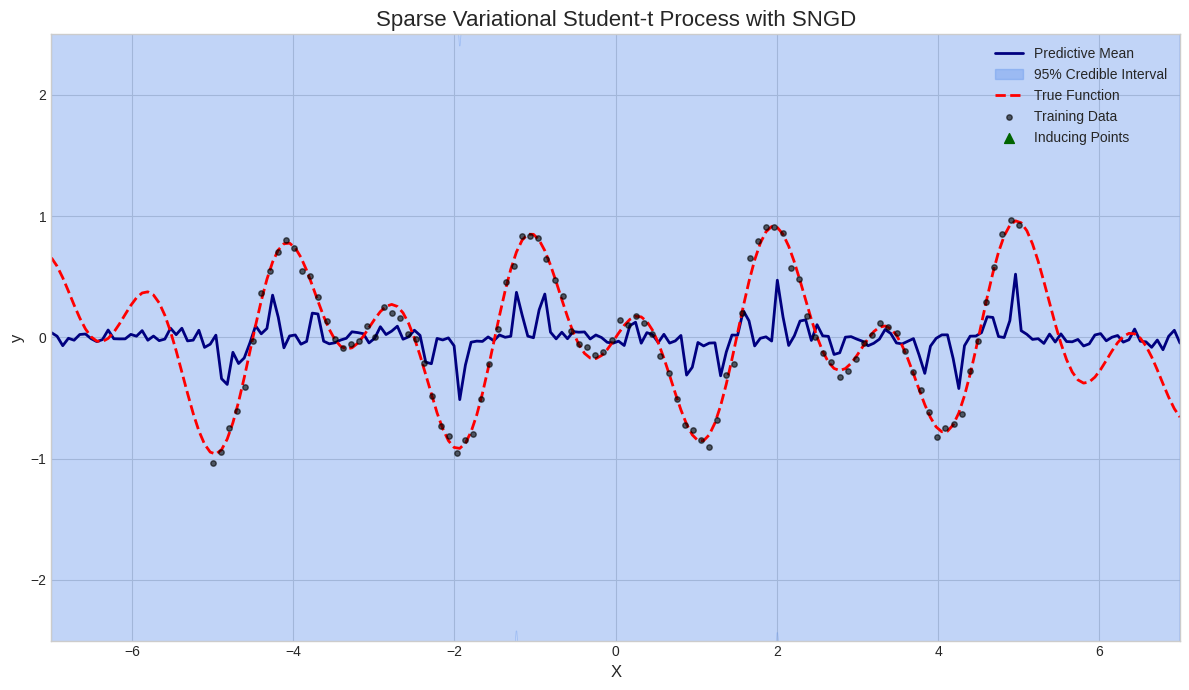

In [15]:
import matplotlib.pyplot as plt
import math

# --- 1. Generate Synthetic Data ---
N = 100  # Number of training points
D = 1    # Input dimension
M = 30   # Number of inducing points

X_train = torch.linspace(-5, 5, N).unsqueeze(1)
y_true = torch.sin(X_train) * torch.cos(0.5 * X_train * (2 * math.pi))
y_train = y_true + torch.randn(N, 1) * 0.05

X_test = torch.linspace(-7, 7, 200).unsqueeze(1)
y_test_true = torch.sin(X_test) * torch.cos(0.5 * X_test * (2 * math.pi))

logging.info(f"Generated data: {N} training points, {X_test.shape[0]} test points.")

# --- 2. Instantiate and Train the Model ---
model = XuSparseTPR(X_train, y_train, M=M)

model.fit_sngd(
    epochs=1000,
    batch_size=128,
    lr_sngd=0.1,      # Natural gradients can often use a larger learning rate
    lr_adam=0.01,
    num_samples=100,   # Number of MC samples for ELBO calculation
    eval_interval=10
)

# --- 3. Make Predictions ---
logging.info("Making predictions on the test set...")
num_pred_samples = 2000
predictive_samples = model.predict(X_test, num_samples=num_pred_samples)

# Calculate predictive mean and uncertainty (quantiles for non-Gaussian preds)
mu_pred = np.mean(predictive_samples, axis=1)
q_lower = np.quantile(predictive_samples, 0.025, axis=1)
q_upper = np.quantile(predictive_samples, 0.975, axis=1)

# --- 4. Plot the Results ---
logging.info("Plotting results...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Plot predictive mean and uncertainty
ax.plot(X_test.numpy(), mu_pred, color='navy', lw=2, label="Predictive Mean")
ax.fill_between(X_test.numpy().squeeze(), q_lower, q_upper, color='cornflowerblue', alpha=0.4, label="95% Credible Interval")

# Plot data and true function
ax.plot(X_test.numpy(), y_test_true.numpy(), color='red', linestyle='--', lw=2, label="True Function")
ax.scatter(X_train.numpy(), y_train.numpy(), c='black', s=15, alpha=0.6, zorder=3, label="Training Data")

# Plot inducing points
inducing_points = model.Z.detach().cpu().numpy()
ax.scatter(inducing_points, [ax.get_ylim()[0]] * M, marker='^', color='darkgreen', s=50, zorder=4, label="Inducing Points")

ax.set_title("Sparse Variational Student-t Process with SNGD", fontsize=16)
ax.set_xlabel("X", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(-2.5, 2.5)
ax.set_xlim(-7, 7)
plt.tight_layout()
plt.show()

